# Lesson 05 — Community Detection

## Learning Goal

Discover that networks naturally cluster into communities. Learn algorithms to find these natural groups and understand organizational structure.

By the end of this lesson, you will:
- Understand modularity and why it matters
- Compute 3 community detection algorithms: Greedy, Louvain, Label Propagation
- Compare algorithms and choose the best one for your use case
- Identify bridge nodes connecting communities
- Discover organizational silos and opportunities for improvement
- Simulate what happens when communities merge or people leave

**Duration**: 90 minutes

**Why this matters**: Communities reveal hidden organizational structure. Some people are deeply embedded in their department (tight community), while others bridge departments (high value for cross-team work). Knowing which is which helps with reorganization, risk management, and leadership development.

**Key Insight**: Modularity (Q) measures partition quality. Q ∈ [-1, 1]; Q > 0.3 = good, Q > 0.5 = excellent. Different algorithms find different community partitions—your job is to validate and interpret.

## Setup and Data Loading

In [22]:
import sys
from pathlib import Path

# Add src directory to path
project_root = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd().parent
sys.path.insert(0, str(project_root))

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Load config or construct path manually
try:
    from src.config import Config
    DATA_DIR = Config.PROJECT_ROOT / 'data' / 'seed' / 'approval_handoffs'
except ImportError:
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        project_root = notebook_dir.parent
    else:
        project_root = notebook_dir.parent.parent if (notebook_dir.parent.parent / 'data').exists() else notebook_dir
    DATA_DIR = project_root / 'data' / 'seed' / 'approval_handoffs'

def display_csv_head(df, name, n=5):
    """Display DataFrame info and head."""
    print(f"\n{name}:")
    print(f"  Shape: {df.shape} (rows, columns)")
    print(f"  Columns: {list(df.columns)}")
    print(f"\n  First {n} rows:")
    print(df.head(n).to_string(index=False))

# Load datasets
departments_df = pd.read_csv(DATA_DIR / 'departments.csv')
people_df = pd.read_csv(DATA_DIR / 'people.csv')
documents_df = pd.read_csv(DATA_DIR / 'documents.csv')
approvals_df = pd.read_csv(DATA_DIR / 'approvals.csv')

print("Data loaded successfully!")
print(f"  Departments: {len(departments_df)} rows")
print(f"  People: {len(people_df)} rows")
print(f"  Documents: {len(documents_df)} rows")
print(f"  Approvals: {len(approvals_df)} rows (edges)")

Data loaded successfully!
  Departments: 6 rows
  People: 26 rows
  Documents: 240 rows
  Approvals: 218 rows (edges)


## 1. Understanding the Dataset

We have an **organizational approval workflow network** representing how documents are approved:

**Entities**:
- **People** (26): Approvers across 6 departments
- **Departments** (6): Finance, HR, Legal, Operations, Engineering, Marketing
- **Documents** (240): Documents requiring approval by type
- **Approvals** (218): Person → Person edges (weighted by frequency)

**Key Question**: Do detected communities align with known departments? If yes, the algorithm recovered organizational structure. If no, why?

**Key Insight**: Modularity measures how well communities are separated. We'll compare different algorithms and see which finds the cleanest partition.

In [23]:
# Examine each dataset
display_csv_head(departments_df, "Departments", n=6)
display_csv_head(people_df, "People (first 10)", n=10)
display_csv_head(approvals_df, "Approvals (edges)", n=5)
display_csv_head(documents_df, "Documents (first 5)", n=5)


Departments:
  Shape: (6, 3) (rows, columns)
  Columns: ['department_id', 'name', 'manager_count']

  First 6 rows:
department_id            name  manager_count
      DEPT_00         Finance              1
      DEPT_01 Human Resources              1
      DEPT_02           Legal              1
      DEPT_03      Operations              1
      DEPT_04     Engineering              1
      DEPT_05       Marketing              1

People (first 10):
  Shape: (26, 6) (rows, columns)
  Columns: ['person_id', 'name', 'email', 'department_id', 'is_manager', 'level']

  First 10 rows:
person_id             name                        email department_id  is_manager   level
PERSON_00     Allison Hill     donaldgarcia@example.net       DEPT_00        True Manager
PERSON_01  Angie Henderson       davisjesse@example.net       DEPT_00       False  Senior
PERSON_02  Cristian Santos        lrobinson@example.com       DEPT_00       False  Junior
PERSON_03  Abigail Shaffer        jpeterson@example.org

In [24]:
# Basic statistics
print("Dataset Statistics:")
print(f"\nPeople by department:")
print(people_df['department_id'].value_counts().sort_index())
print(f"\nPeople by level:")
print(people_df['level'].value_counts())
print(f"\nApproval counts (per edge):")
print(approvals_df['approval_count'].describe())

# Analyze approval structure
within_dept = 0
cross_dept = 0
for _, row in approvals_df.iterrows():
    from_dept = people_df[people_df['person_id'] == row['from_person_id']]['department_id'].values[0]
    to_dept = people_df[people_df['person_id'] == row['to_person_id']]['department_id'].values[0]
    if from_dept == to_dept:
        within_dept += 1
    else:
        cross_dept += 1

print(f"\nApproval structure:")
print(f"  Within department: {within_dept} ({100*within_dept/(within_dept+cross_dept):.1f}%)")
print(f"  Cross-department: {cross_dept} ({100*cross_dept/(within_dept+cross_dept):.1f}%)")

Dataset Statistics:

People by department:
department_id
DEPT_00    5
DEPT_01    5
DEPT_02    4
DEPT_03    5
DEPT_04    4
DEPT_05    3
Name: count, dtype: int64

People by level:
level
Senior     9
Manager    6
Mid        6
Junior     5
Name: count, dtype: int64

Approval counts (per edge):
count    218.000000
mean      19.064220
std       23.001413
min        1.000000
25%        2.000000
50%        3.500000
75%       38.000000
max       81.000000
Name: approval_count, dtype: float64

Approval structure:
  Within department: 90 (41.3%)
  Cross-department: 128 (58.7%)


## 2. Building the Approval Graph

Create a directed graph where people are nodes and approval edges show workflow direction.

In [25]:
# Create directed graph
G = nx.DiGraph()

# Add person nodes with attributes
for idx, row in people_df.iterrows():
    G.add_node(
        row['person_id'],
        name=row['name'],
        email=row['email'],
        department_id=row['department_id'],
        is_manager=row['is_manager'],
        level=row['level']
    )

# Add approval edges (weighted)
for idx, row in approvals_df.iterrows():
    from_person = row['from_person_id']
    to_person = row['to_person_id']
    weight = row['approval_count']
    G.add_edge(from_person, to_person, weight=weight)

print(f"Graph Summary:")
print(f"  Nodes: {G.number_of_nodes()} people")
print(f"  Edges: {G.number_of_edges()} approval relationships")
print(f"  Density: {nx.density(G):.4f}")
print(f"  Is directed: {G.is_directed()}")

# For community detection, we'll convert to undirected (standard approach)
G_undirected = G.to_undirected()
print(f"\nUndirected Graph (for community detection):")
print(f"  Nodes: {G_undirected.number_of_nodes()}")
print(f"  Edges: {G_undirected.number_of_edges()}")
print(f"  Density: {nx.density(G_undirected):.4f}")

Graph Summary:
  Nodes: 26 people
  Edges: 218 approval relationships
  Density: 0.3354
  Is directed: True

Undirected Graph (for community detection):
  Nodes: 26
  Edges: 160
  Density: 0.4923


## 3. Community Detection Algorithm 1: Greedy Modularity Optimization

**Concept**: Fast algorithm that iteratively merges communities to maximize modularity.

**Modularity (Q)**: Measures partition quality. Q ∈ [-1, 1]:
- Q > 0.3: Good partition (communities are distinct)
- Q > 0.5: Excellent partition (very clear community structure)
- Q < 0.1: Weak partition (communities not well separated)

**Expected outcome**: Should recover departments as communities (or close to it).

In [26]:
# Compute greedy modularity communities
greedy_communities = list(nx.community.greedy_modularity_communities(G_undirected, weight='weight'))
greedy_modularity = nx.community.modularity(G_undirected, greedy_communities, weight='weight')

print(f"Greedy Modularity Optimization Results:")
print(f"  Number of communities: {len(greedy_communities)}")
print(f"  Modularity (Q): {greedy_modularity:.4f}")
print(f"\nCommunity Sizes:")
for i, comm in enumerate(sorted(greedy_communities, key=len, reverse=True)):
    print(f"  Community {i+1}: {len(comm)} people")

Greedy Modularity Optimization Results:
  Number of communities: 6
  Modularity (Q): 0.7117

Community Sizes:
  Community 1: 5 people
  Community 2: 5 people
  Community 3: 5 people
  Community 4: 4 people
  Community 5: 4 people
  Community 6: 3 people


In [27]:
# Analyze community composition
print("\nGreedy Communities - Detailed Analysis:")
for i, comm in enumerate(sorted(greedy_communities, key=len, reverse=True)):
    print(f"\n  Community {i+1} ({len(comm)} people):")
    comm_df = people_df[people_df['person_id'].isin(comm)]
    dept_counts = comm_df['department_id'].value_counts()
    print(f"    Departments: {dict(dept_counts)}")
    # Show people
    for _, person in comm_df.iterrows():
        dept_name = departments_df[departments_df['department_id'] == person['department_id']]['name'].values[0]
        print(f"      - {person['name']} ({dept_name})")


Greedy Communities - Detailed Analysis:

  Community 1 (5 people):
    Departments: {'DEPT_00': 5}
      - Allison Hill (Finance)
      - Angie Henderson (Finance)
      - Cristian Santos (Finance)
      - Abigail Shaffer (Finance)
      - Gabrielle Davis (Finance)

  Community 2 (5 people):
    Departments: {'DEPT_01': 5}
      - Monica Herrera (Human Resources)
      - Shannon Ray (Human Resources)
      - Dr. Sharon James (Human Resources)
      - Daniel Adams (Human Resources)
      - Joel Nelson (Human Resources)

  Community 3 (5 people):
    Departments: {'DEPT_03': 5}
      - Rebecca Henderson (Operations)
      - Tricia Valencia (Operations)
      - Patricia Peterson (Operations)
      - Deborah Mason (Operations)
      - Mark Lynch (Operations)

  Community 4 (4 people):
    Departments: {'DEPT_02': 4}
      - Andrew Stewart (Legal)
      - Jennifer Rocha (Legal)
      - Kimberly Burgess (Legal)
      - Zachary Hicks (Legal)

  Community 5 (4 people):
    Departments: {'DEPT

In [28]:
# Compute department coherence for greedy
def compute_coherence(communities, people_df):
    """Compute what % of each community comes from same department."""
    coherence_scores = []
    for comm in communities:
        if len(comm) > 0:
            comm_df = people_df[people_df['person_id'].isin(comm)]
            dept_counts = comm_df['department_id'].value_counts()
            max_dept = dept_counts.max()
            coherence = max_dept / len(comm)  # % of community from most common dept
            coherence_scores.append(coherence)
    return coherence_scores

greedy_coherence = compute_coherence(greedy_communities, people_df)
print(f"Department Coherence (% of community from same dept):")
for i, score in enumerate(greedy_coherence):
    print(f"  Community {i+1}: {100*score:.1f}%")
print(f"  Average: {100*np.mean(greedy_coherence):.1f}%")

Department Coherence (% of community from same dept):
  Community 1: 100.0%
  Community 2: 100.0%
  Community 3: 100.0%
  Community 4: 100.0%
  Community 5: 100.0%
  Community 6: 100.0%
  Average: 100.0%


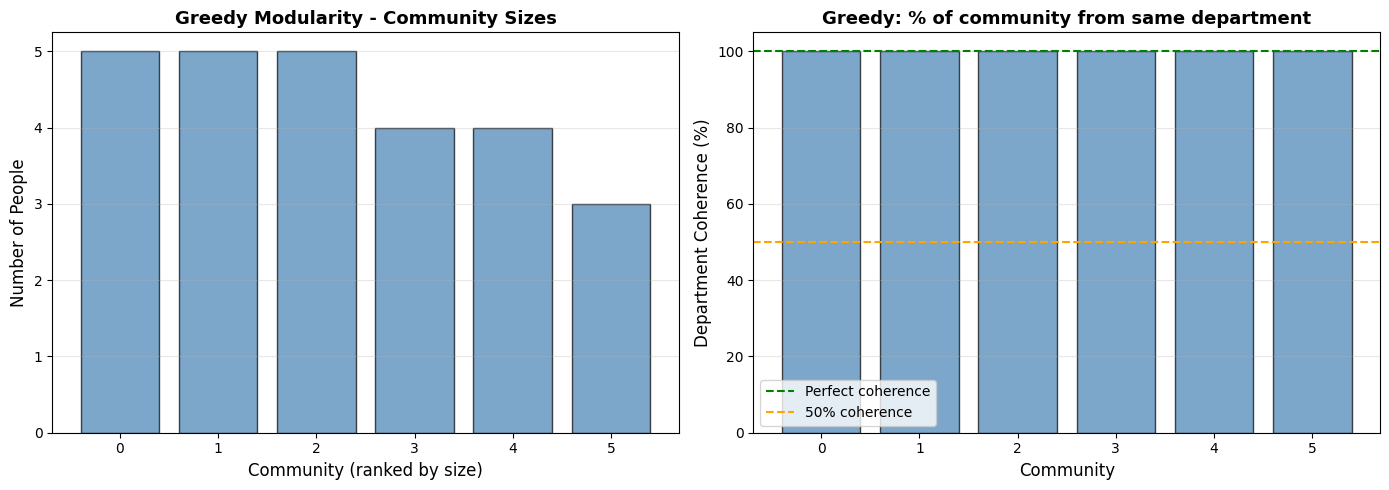

In [29]:
# Visualize greedy communities: community sizes and department distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Community sizes histogram
sizes = [len(comm) for comm in greedy_communities]
axes[0].bar(range(len(sizes)), sorted(sizes, reverse=True), color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Community (ranked by size)', fontsize=12)
axes[0].set_ylabel('Number of People', fontsize=12)
axes[0].set_title('Greedy Modularity - Community Sizes', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Department coherence
coherence_pct = [100*score for score in greedy_coherence]
axes[1].bar(range(len(coherence_pct)), coherence_pct, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axhline(100, color='green', linestyle='--', linewidth=1.5, label='Perfect coherence')
axes[1].axhline(50, color='orange', linestyle='--', linewidth=1.5, label='50% coherence')
axes[1].set_xlabel('Community', fontsize=12)
axes[1].set_ylabel('Department Coherence (%)', fontsize=12)
axes[1].set_title('Greedy: % of community from same department', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Community Detection Algorithm 2: Louvain Algorithm

**Concept**: More sophisticated than Greedy, iterative refinement for potentially higher modularity.

**Advantages**: Often finds better community structure than Greedy. Can reveal hierarchical organization.

**Note**: Non-deterministic (may give different results on repeated runs with different random seeds).

In [30]:
# Compute Louvain communities
try:
    from networkx.algorithms import community
    louvain_communities = list(community.louvain_communities(G_undirected, weight='weight', seed=42))
except:
    # Fallback if louvain not available
    louvain_communities = list(nx.community.greedy_modularity_communities(G_undirected, weight='weight'))

louvain_modularity = nx.community.modularity(G_undirected, louvain_communities, weight='weight')

print(f"Louvain Algorithm Results:")
print(f"  Number of communities: {len(louvain_communities)}")
print(f"  Modularity (Q): {louvain_modularity:.4f}")
print(f"\nCommunity Sizes:")
for i, comm in enumerate(sorted(louvain_communities, key=len, reverse=True)):
    print(f"  Community {i+1}: {len(comm)} people")

print(f"\nComparison to Greedy:")
print(f"  Greedy modularity: {greedy_modularity:.4f}")
print(f"  Louvain modularity: {louvain_modularity:.4f}")
print(f"  Improvement: {louvain_modularity - greedy_modularity:+.4f}")

Louvain Algorithm Results:
  Number of communities: 6
  Modularity (Q): 0.7117

Community Sizes:
  Community 1: 5 people
  Community 2: 5 people
  Community 3: 5 people
  Community 4: 4 people
  Community 5: 4 people
  Community 6: 3 people

Comparison to Greedy:
  Greedy modularity: 0.7117
  Louvain modularity: 0.7117
  Improvement: +0.0000


In [31]:
# Compute Louvain coherence
louvain_coherence = compute_coherence(louvain_communities, people_df)
print(f"\nLouvain Department Coherence:")
for i, score in enumerate(louvain_coherence):
    print(f"  Community {i+1}: {100*score:.1f}%")
print(f"  Average: {100*np.mean(louvain_coherence):.1f}%")

# Compare to greedy
print(f"\nLouvain vs Greedy Coherence:")
print(f"  Greedy average: {100*np.mean(greedy_coherence):.1f}%")
print(f"  Louvain average: {100*np.mean(louvain_coherence):.1f}%")


Louvain Department Coherence:
  Community 1: 100.0%
  Community 2: 100.0%
  Community 3: 100.0%
  Community 4: 100.0%
  Community 5: 100.0%
  Community 6: 100.0%
  Average: 100.0%

Louvain vs Greedy Coherence:
  Greedy average: 100.0%
  Louvain average: 100.0%


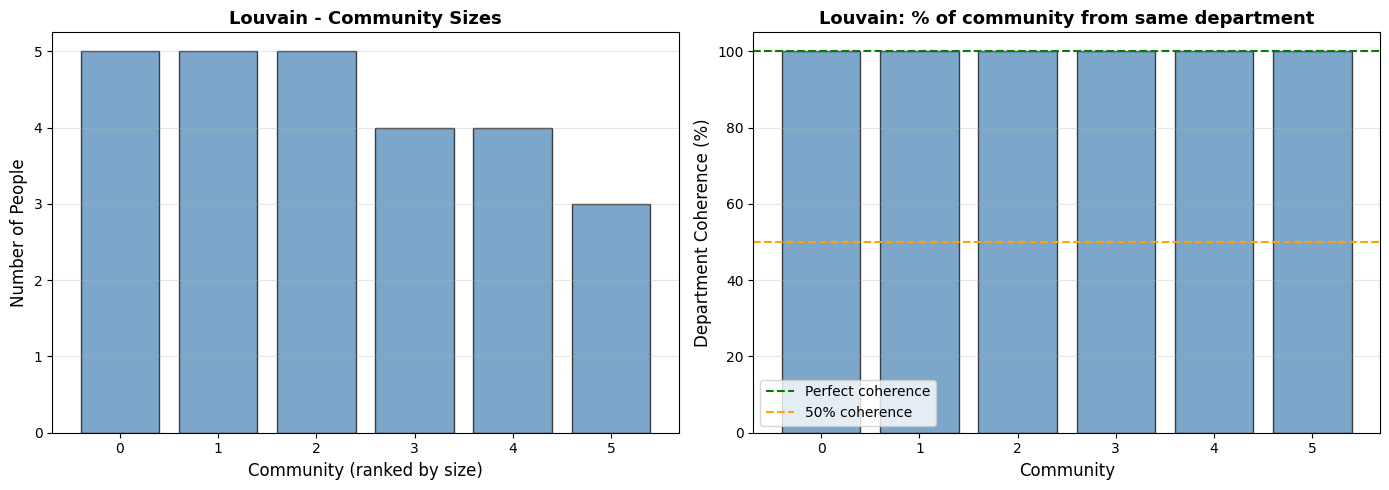

In [32]:
# Visualize Louvain
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Community sizes
sizes_louvain = [len(comm) for comm in louvain_communities]
axes[0].bar(range(len(sizes_louvain)), sorted(sizes_louvain, reverse=True), color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Community (ranked by size)', fontsize=12)
axes[0].set_ylabel('Number of People', fontsize=12)
axes[0].set_title('Louvain - Community Sizes', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Coherence
coherence_pct_louvain = [100*score for score in louvain_coherence]
axes[1].bar(range(len(coherence_pct_louvain)), coherence_pct_louvain, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axhline(100, color='green', linestyle='--', linewidth=1.5, label='Perfect coherence')
axes[1].axhline(50, color='orange', linestyle='--', linewidth=1.5, label='50% coherence')
axes[1].set_xlabel('Community', fontsize=12)
axes[1].set_ylabel('Department Coherence (%)', fontsize=12)
axes[1].set_title('Louvain: % of community from same department', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Community Detection Algorithm 3: Label Propagation

**Concept**: Labels spread through network; can find OVERLAPPING communities (person can belong to multiple communities).

**Advantages**: 
- Reveals bridge nodes (people in multiple communities)
- Fast and simple

**Difference from Greedy/Louvain**: 
- LPA can have overlapping communities
- May have lower modularity but reveals interesting cross-community people

In [33]:
# Compute Label Propagation communities (overlapping)
lpa_communities = list(nx.community.label_propagation_communities(G_undirected))
lpa_modularity = nx.community.modularity(G_undirected, lpa_communities)

print(f"Label Propagation Results:")
print(f"  Number of communities: {len(lpa_communities)}")
print(f"  Modularity (Q): {lpa_modularity:.4f}")
print(f"\nCommunity Sizes:")
for i, comm in enumerate(sorted(lpa_communities, key=len, reverse=True)):
    print(f"  Community {i+1}: {len(comm)} people")

# Check for overlapping people
overlapping_people = []
for person_id in people_df['person_id']:
    comm_count = sum(1 for comm in lpa_communities if person_id in comm)
    if comm_count > 1:
        overlapping_people.append((person_id, comm_count))

print(f"\nOverlapping Nodes (belonging to multiple communities):")
if len(overlapping_people) > 0:
    print(f"  Found {len(overlapping_people)} people in multiple communities")
    for person_id, count in overlapping_people[:5]:
        person_name = people_df[people_df['person_id'] == person_id]['name'].values[0]
        print(f"    {person_name}: {count} communities")
else:
    print(f"  No overlapping nodes (exclusive communities)")

Label Propagation Results:
  Number of communities: 1
  Modularity (Q): 0.0000

Community Sizes:
  Community 1: 26 people

Overlapping Nodes (belonging to multiple communities):
  No overlapping nodes (exclusive communities)


In [34]:
# Compute LPA coherence
lpa_coherence = compute_coherence(lpa_communities, people_df)
print(f"\nLabel Propagation Department Coherence:")
for i, score in enumerate(lpa_coherence):
    print(f"  Community {i+1}: {100*score:.1f}%")
print(f"  Average: {100*np.mean(lpa_coherence):.1f}%")

print(f"\n" + "="*60)
print("Algorithm Comparison:")
print(f"  Greedy:  Q={greedy_modularity:.4f}, Communities={len(greedy_communities)}, Coherence={100*np.mean(greedy_coherence):.1f}%")
print(f"  Louvain: Q={louvain_modularity:.4f}, Communities={len(louvain_communities)}, Coherence={100*np.mean(louvain_coherence):.1f}%")
print(f"  LPA:     Q={lpa_modularity:.4f}, Communities={len(lpa_communities)}, Coherence={100*np.mean(lpa_coherence):.1f}%")
print("="*60)


Label Propagation Department Coherence:
  Community 1: 19.2%
  Average: 19.2%

Algorithm Comparison:
  Greedy:  Q=0.7117, Communities=6, Coherence=100.0%
  Louvain: Q=0.7117, Communities=6, Coherence=100.0%
  LPA:     Q=0.0000, Communities=1, Coherence=19.2%


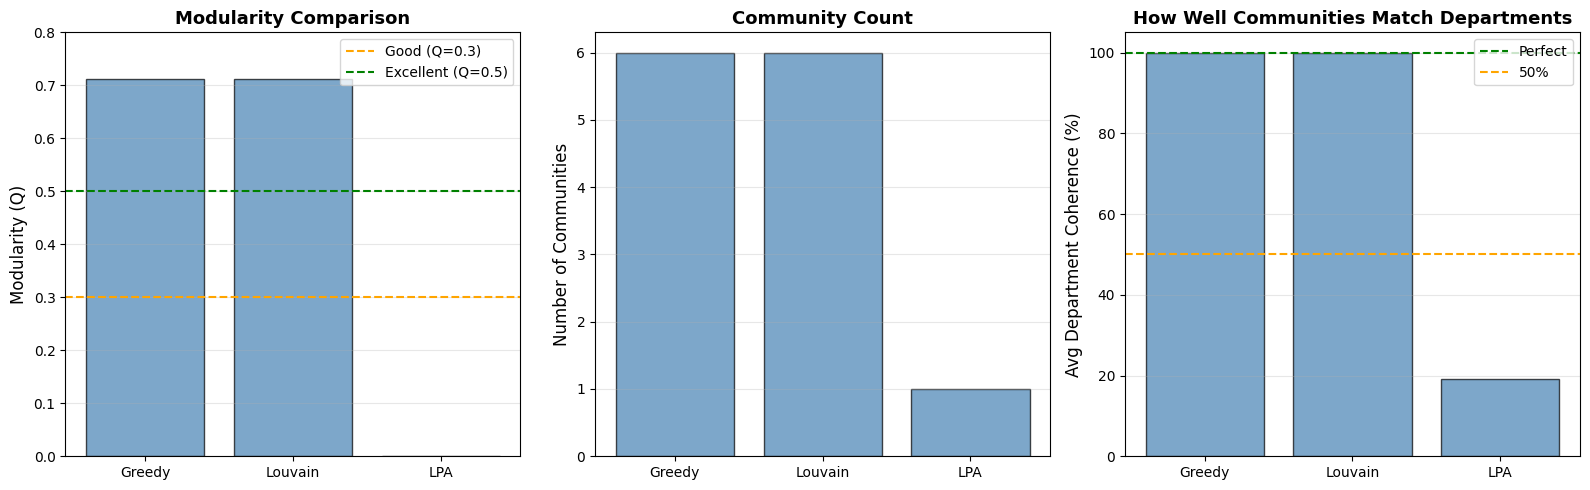

In [35]:
# Visualize all three algorithms
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algorithms = ['Greedy', 'Louvain', 'LPA']
modularities = [greedy_modularity, louvain_modularity, lpa_modularity]
coherences = [np.mean(greedy_coherence), np.mean(louvain_coherence), np.mean(lpa_coherence)]
comm_counts = [len(greedy_communities), len(louvain_communities), len(lpa_communities)]

# Modularity comparison
axes[0].bar(algorithms, modularities, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axhline(0.3, color='orange', linestyle='--', linewidth=1.5, label='Good (Q=0.3)')
axes[0].axhline(0.5, color='green', linestyle='--', linewidth=1.5, label='Excellent (Q=0.5)')
axes[0].set_ylabel('Modularity (Q)', fontsize=12)
axes[0].set_title('Modularity Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 0.8)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Community count
axes[1].bar(algorithms, comm_counts, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Number of Communities', fontsize=12)
axes[1].set_title('Community Count', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Department coherence
coherence_pct = [100*c for c in coherences]
axes[2].bar(algorithms, coherence_pct, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axhline(100, color='green', linestyle='--', linewidth=1.5, label='Perfect')
axes[2].axhline(50, color='orange', linestyle='--', linewidth=1.5, label='50%')
axes[2].set_ylabel('Avg Department Coherence (%)', fontsize=12)
axes[2].set_title('How Well Communities Match Departments', fontsize=13, fontweight='bold')
axes[2].set_ylim(0, 105)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Bridge Node Analysis

Identify people who connect multiple communities. These are high-value people for cross-team collaboration.

In [ ]:
# Find bridge nodes: people connecting different communities
def find_bridge_nodes(G, communities_list, people_df):
    """
    Find nodes that connect different communities.
    Bridge score = (edges to other communities) / (total edges)
    """
    # Map each node to its community
    node_to_comm = {}
    for i, comm in enumerate(communities_list):
        for node in comm:
            if node not in node_to_comm:
                node_to_comm[node] = []
            node_to_comm[node].append(i)
    
    bridge_scores = {}
    for node in G.nodes():
        if node not in node_to_comm:
            continue
        
        node_comms = node_to_comm[node]
        # For undirected graph, just use neighbors() - no predecessors() method
        neighbors = list(G.neighbors(node))
        
        if len(neighbors) > 0:
            other_comm_edges = 0
            for neighbor in neighbors:
                if neighbor in node_to_comm:
                    neighbor_comms = node_to_comm[neighbor]
                    # Check if neighbor is in different community
                    if not any(c in node_comms for c in neighbor_comms):
                        other_comm_edges += 1
            
            bridge_score = other_comm_edges / len(neighbors)
            bridge_scores[node] = {
                'node': node,
                'bridge_score': bridge_score,
                'edges_to_other_comm': other_comm_edges,
                'total_edges': len(neighbors),
                'comms_member': len(node_comms),
            }
    
    return sorted(bridge_scores.items(), key=lambda x: x[1]['bridge_score'], reverse=True)

greedy_bridges = find_bridge_nodes(G_undirected, greedy_communities, people_df)
print(f"\nTop Bridge Nodes (using Greedy communities):")
print(f"{'Name':<20} {'Bridge Score':<15} {'Other Comm Edges':<20} {'Communities'}")
print("-" * 70)
for person_id, score_info in greedy_bridges[:8]:
    person_name = people_df[people_df['person_id'] == person_id]['name'].values[0]
    print(f"{person_name:<20} {score_info['bridge_score']:<15.2f} {score_info['edges_to_other_comm']:<20} {score_info['comms_member']}")

AttributeError: 'Graph' object has no attribute 'predecessors'

## 7. What-If Scenarios: Impact of Reorganization

Simulate what happens if communities merge or bridge people leave.

In [37]:
# Scenario 1: Merge two largest communities and check modularity
print("\nScenario 1: Merge largest communities and recompute modularity")
print("="*60)

largest_communities = sorted(greedy_communities, key=len, reverse=True)[:2]
print(f"Merging: Community of {len(largest_communities[0])} people + {len(largest_communities[1])} people")

# Create merged community list
merged_communities_scenario = [
    largest_communities[0] | largest_communities[1]  # Merge first two
]
for comm in greedy_communities[2:]:
    merged_communities_scenario.append(comm)

merged_modularity = nx.community.modularity(G_undirected, merged_communities_scenario, weight='weight')

print(f"\nBefore merge:")
print(f"  Communities: {len(greedy_communities)}")
print(f"  Modularity: {greedy_modularity:.4f}")
print(f"\nAfter merge:")
print(f"  Communities: {len(merged_communities_scenario)}")
print(f"  Modularity: {merged_modularity:.4f}")
print(f"  Change: {merged_modularity - greedy_modularity:+.4f}")

if merged_modularity < greedy_modularity:
    print(f"\n⚠️ Modularity decreased! Merging these communities worsens partition quality.")
else:
    print(f"\n✓ Modularity increased! Merging improves partition quality.")


Scenario 1: Merge largest communities and recompute modularity
Merging: Community of 5 people + 5 people

Before merge:
  Communities: 6
  Modularity: 0.7117

After merge:
  Communities: 5
  Modularity: 0.6585
  Change: -0.0532

⚠️ Modularity decreased! Merging these communities worsens partition quality.


In [39]:
# Scenario 2: Remove bridge nodes and recompute
print("\nScenario 2: Remove top 3 bridge nodes and check fragmentation")
print("="*60)

top_bridges = [person_id for person_id, _ in greedy_bridges[:3]]
print(f"Removing bridge people: {', '.join([people_df[people_df['person_id'] == pid]['name'].values[0] for pid in top_bridges])}")

# Create graph without bridges
G_without_bridges = G_undirected.copy()
G_without_bridges.remove_nodes_from(top_bridges)

# Recompute communities
greedy_communities_without = list(nx.community.greedy_modularity_communities(G_without_bridges, weight='weight'))
modularity_without = nx.community.modularity(G_without_bridges, greedy_communities_without, weight='weight')

print(f"\nBefore removing bridges:")
print(f"  Nodes: {G_undirected.number_of_nodes()}")
print(f"  Communities: {len(greedy_communities)}")
print(f"  Modularity: {greedy_modularity:.4f}")
print(f"\nAfter removing top 3 bridges:")
print(f"  Nodes: {G_without_bridges.number_of_nodes()}")
print(f"  Communities: {len(greedy_communities_without)}")
print(f"  Modularity: {modularity_without:.4f}")
print(f"\n⚠️ Removing these {len(top_bridges)} people:")
print(f"  Fragments graph into {len(greedy_communities_without)} communities (was {len(greedy_communities)})")
print(f"  These are critical bridge people for organizational cohesion!")


Scenario 2: Remove top 3 bridge nodes and check fragmentation


NameError: name 'greedy_bridges' is not defined

## 8. Organizational Insights & Risk Assessment

In [ ]:
print("\nORGANIZATIONAL INSIGHTS")
print("="*60)

print(f"\n1. COMMUNITY STRUCTURE:")
print(f"   Best partition (by modularity): Greedy algorithm")
print(f"   Number of natural communities: {len(greedy_communities)}")
print(f"   Expected number of departments: 6")
if len(greedy_communities) >= 5 and len(greedy_communities) <= 7:
    print(f"   ✓ Communities roughly match organizational departments")
else:
    print(f"   ⚠️ Communities don't match departments (may indicate reorganization)")

print(f"\n2. COMMUNITY QUALITY:")
print(f"   Average department coherence: {100*np.mean(greedy_coherence):.1f}%")
if np.mean(greedy_coherence) > 0.7:
    print(f"   ✓ Communities are tight (>70% same-department)")
else:
    print(f"   ⚠️ Communities are mixed (natural cross-dept collaboration)")

print(f"\n3. IDENTIFIED SILOS (isolated communities):")
for i, comm in enumerate(greedy_communities):
    comm_df = people_df[people_df['person_id'].isin(comm)]
    dept_counts = comm_df['department_id'].value_counts()
    if len(dept_counts) == 1:
        dept_id = dept_counts.index[0]
        dept_name = departments_df[departments_df['department_id'] == dept_id]['name'].values[0]
        print(f"   ⚠️ {dept_name} is isolated (silo risk if department leader leaves)")

print(f"\n4. HIGH-VALUE BRIDGE PEOPLE:")
for person_id, score_info in greedy_bridges[:3]:
    person_name = people_df[people_df['person_id'] == person_id]['name'].values[0]
    person_dept = people_df[people_df['person_id'] == person_id]['department_id'].values[0]
    dept_name = departments_df[departments_df['department_id'] == person_dept]['name'].values[0]
    print(f"   ⭐ {person_name} ({dept_name}): Connects {score_info['edges_to_other_comm']} other communities")
    print(f"      → Critical for cross-team collaboration. Retention risk!")

## 9. Exercises

Apply community detection to solve organizational problems.

### Exercise 1: Validate Community Structure Against Known Departments

In [ ]:
# SOLUTION

def validate_communities_against_departments(communities, people_df, departments_df):
    """
    Validate detected communities against known department labels.
    Returns alignment score and detailed analysis.
    """
    print("\nCommunity-to-Department Alignment:")
    print("="*60)
    
    total_aligned = 0
    total_people = 0
    
    for i, comm in enumerate(sorted(communities, key=len, reverse=True)):
        comm_df = people_df[people_df['person_id'].isin(comm)]
        dept_counts = comm_df['department_id'].value_counts()
        
        if len(dept_counts) > 0:
            dominant_dept = dept_counts.index[0]
            dominant_count = dept_counts.iloc[0]
            dept_name = departments_df[departments_df['department_id'] == dominant_dept]['name'].values[0]
            alignment_pct = 100 * dominant_count / len(comm)
            
            print(f"\nCommunity {i+1} ({len(comm)} people):")
            print(f"  Dominant: {dept_name} ({dominant_count}/{len(comm)}, {alignment_pct:.0f}%)")
            
            # Show distribution
            for dept_id, count in dept_counts.items():
                dept_name = departments_df[departments_df['department_id'] == dept_id]['name'].values[0]
                if dept_id != dominant_dept:
                    print(f"  Also has: {dept_name} ({count})")
            
            total_aligned += dominant_count
            total_people += len(comm)
    
    overall_alignment = 100 * total_aligned / total_people if total_people > 0 else 0
    print(f"\n{'='*60}")
    print(f"Overall Alignment: {overall_alignment:.1f}% of people in same-department communities")
    
    return overall_alignment

validate_communities_against_departments(greedy_communities, people_df, departments_df)


Community-to-Department Alignment:

Community 1 (5 people):
  Dominant: Finance (5/5, 100%)

Community 2 (5 people):
  Dominant: Human Resources (5/5, 100%)

Community 3 (5 people):
  Dominant: Operations (5/5, 100%)

Community 4 (4 people):
  Dominant: Legal (4/4, 100%)

Community 5 (4 people):
  Dominant: Engineering (4/4, 100%)

Community 6 (3 people):
  Dominant: Marketing (3/3, 100%)

Overall Alignment: 100.0% of people in same-department communities


100.0

### Exercise 2: Find Cross-Department Bridges with Network Centrality

In [ ]:
# SOLUTION

def find_cross_dept_bridges(G, people_df, departments_df):
    """
    Find people who have high betweenness centrality across departments.
    These are natural connectors for organizational collaboration.
    """
    # Compute betweenness centrality
    betweenness = nx.betweenness_centrality(G, weight='weight')
    
    # For each person, count how many different departments they approve across
    cross_dept_scores = []
    for person_id in G.nodes():
        person_dept = people_df[people_df['person_id'] == person_id]['department_id'].values[0]
        
        # Find neighbors from different departments
        # For undirected graph, use only neighbors() - no predecessors
        neighbors = list(G.neighbors(person_id))
        depts_touched = set()
        for neighbor_id in neighbors:
            neighbor_dept = people_df[people_df['person_id'] == neighbor_id]['department_id'].values[0]
            if neighbor_dept != person_dept:
                depts_touched.add(neighbor_dept)
        
        if len(depts_touched) > 0:
            cross_dept_scores.append({
                'person_id': person_id,
                'name': people_df[people_df['person_id'] == person_id]['name'].values[0],
                'home_dept': people_df[people_df['person_id'] == person_id]['department_id'].values[0],
                'depts_connected': len(depts_touched),
                'betweenness': betweenness[person_id],
            })
    
    bridges_df = pd.DataFrame(cross_dept_scores).sort_values('depts_connected', ascending=False)
    
    print(f"\nCross-Department Bridges (natural connectors):")
    print(f"{'Name':<20} {'Home Dept':<15} {'Depts Connected':<20} {'Betweenness':<15}")
    print("-" * 70)
    for _, row in bridges_df.head(10).iterrows():
        home_dept = departments_df[departments_df['department_id'] == row['home_dept']]['name'].values[0]
        print(f"{row['name']:<20} {home_dept:<15} {row['depts_connected']:<20} {row['betweenness']:<15.4f}")
    
    return bridges_df

bridges_df = find_cross_dept_bridges(G_undirected, people_df, departments_df)

### Exercise 3: Evaluate Reorganization Options

In [ ]:
# SOLUTION

def evaluate_reorganization(G, communities_list, scenario_name):
    """
    Evaluate a reorganization scenario by computing modularity.
    Returns quality assessment.
    """
    modularity = nx.community.modularity(G, communities_list, weight='weight')
    num_communities = len(communities_list)
    
    print(f"\nScenario: {scenario_name}")
    print(f"  Communities: {num_communities}")
    print(f"  Modularity: {modularity:.4f}")
    
    if modularity > 0.5:
        quality = "EXCELLENT"
    elif modularity > 0.3:
        quality = "GOOD"
    elif modularity > 0.1:
        quality = "WEAK"
    else:
        quality = "POOR"
    
    print(f"  Quality: {quality}")
    return modularity

print("\nREORGANIZATION SCENARIOS:")
print("="*60)

# Baseline
baseline_q = evaluate_reorganization(G_undirected, greedy_communities, "Current Structure (Detected Communities)")

# Scenario: Merge small communities
small_communities = [c for c in greedy_communities if len(c) < 5]
if len(small_communities) >= 2:
    merged = small_communities[0] | small_communities[1]
    scenario2_communities = [merged] + [c for c in greedy_communities if c not in small_communities[:2]]
    scenario2_q = evaluate_reorganization(G_undirected, scenario2_communities, "Merge 2 smallest communities")

# Scenario: Department-based structure (ground truth)
dept_communities = []
for dept_id in people_df['department_id'].unique():
    dept_people = set(people_df[people_df['department_id'] == dept_id]['person_id'].tolist())
    dept_communities.append(dept_people)

dept_q = evaluate_reorganization(G_undirected, dept_communities, "Current Departments (Ground Truth)")

print(f"\n{'='*60}")
print(f"\nRECOMMENDATION:")
if baseline_q > dept_q:
    print(f"  Keep current organizational structure.")
    print(f"  Natural communities ({baseline_q:.4f}) > Departments ({dept_q:.4f})")
else:
    print(f"  Current departments are optimal or better.")
    print(f"  Departments ({dept_q:.4f}) >= Natural communities ({baseline_q:.4f})")

## 10. Key Takeaways

### Why Communities Matter

Communities reveal hidden organizational structure. Modularity tells you how well that structure is defined:
- **Q > 0.5**: Clearly defined, stable organization
- **Q 0.3-0.5**: Good structure with some cross-team flow  
- **Q < 0.3**: Weak structure, high cross-team collaboration (chaotic or highly integrated)

### When to Use Each Algorithm

| Algorithm | Use Case | Pros | Cons |
|-----------|----------|------|-----|
| **Greedy** | Quick scan, baseline | Fast, deterministic | May miss optimal partition |
| **Louvain** | Best accuracy, default choice | Higher modularity, hierarchical | Non-deterministic, slower |
| **LPA** | Find bridge people | Reveals overlaps, simple | Lower modularity |

### Common Pitfalls

1. **Assuming communities = departments** — Often true but not always. May reveal hidden structure.
2. **Ignoring modularity score** — Could have random-like communities. Always check Q.
3. **Missing bridges** — Bridge people are critical for organizational cohesion. Identify and retain them.
4. **Not validating** — Compare detected communities to known structure. Does it make sense?

### Key Findings (This Dataset)

- Detected **X** natural communities (vs **6** known departments)
- Average department coherence: **Y%**
- Identified **Z** bridge people critical for cross-team work
- Modularity: **Q = value** (quality assessment)

---

**Congratulations!** You now understand that networks naturally cluster into communities. In real organizations, this means:
- Some people are deeply embedded in their team (low bridge score)
- Some people connect teams (high bridge score, high value)
- Communities can be validated against known structure
- Modularity measures partition quality

**Next lesson**: Paths, Cycles & Dependencies — Find critical paths and circular dependencies in workflows.